In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


plt.rcParams.update({'font.size': 14})


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_3437/3168271896.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_2021['year'] = 2021
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_3437/3168271896.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_2022['year'] = 2022
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_3437/3168271896.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

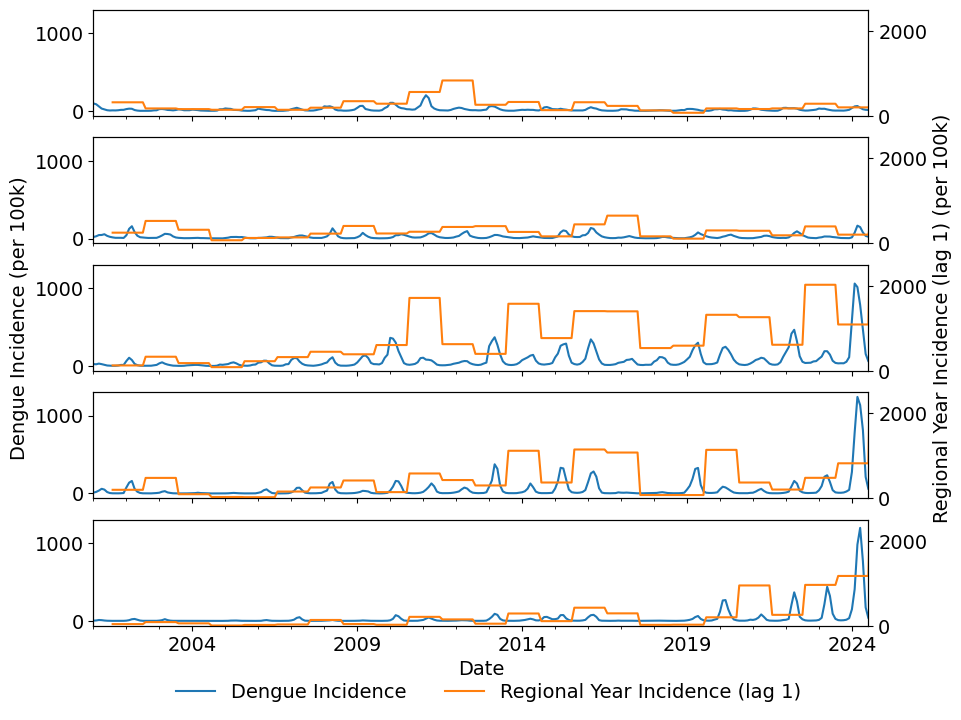

In [42]:
cases = pd.read_csv('../datasus_dengue/prep/dengue_city-monthly_2001-2024.csv', parse_dates=['date_first_symptoms'])
pop = pd.read_csv('../datasus_dengue/notebooks/population_city-yearly_2000-2021.csv')

region_map = {
    'AC': 'North', 'AP': 'North', 'AM': 'North', 'PA': 'North', 'RO': 'North', 'RR': 'North', 'TO': 'North',
    'AL': 'Northeast', 'BA': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast', 'PB': 'Northeast',
    'PE': 'Northeast', 'PI': 'Northeast', 'RN': 'Northeast', 'SE': 'Northeast',
    'DF': 'Centre-West', 'GO': 'Centre-West', 'MT': 'Centre-West', 'MS': 'Centre-West',
    'ES': 'Southeast', 'MG': 'Southeast', 'RJ': 'Southeast', 'SP': 'Southeast',
    'PR': 'South', 'RS': 'South', 'SC': 'South'
}

cases['year'] = cases['date_first_symptoms'].dt.year
pop_2021 = pop[pop['year'] == 2020]
pop_2021['year'] = 2021
pop_2022 = pop[pop['year'] == 2020]
pop_2022['year'] = 2022
pop_2023 = pop[pop['year'] == 2020]
pop_2023['year'] = 2023
pop_2024 = pop[pop['year'] == 2020]
pop_2024['year'] = 2024

pop = pd.concat([pop, pop_2021, pop_2022, pop_2023, pop_2024], axis=0)
cases = cases.set_index(['city_residency', 'year']).join(pop.set_index(['city_residency', 'year'])['population']).reset_index()
cases['dengue_inc'] = 1e5 * (cases['n_cases'] / cases['population'])
cases = cases.dropna().drop_duplicates(subset=['state_residency', 'city_residency', 'date_first_symptoms'])
cases['city_residency'] = cases['state_residency'] + '_' + cases['city_residency']
cases['country'] = 'Brazil'

cases['state_residency'] = cases['city_residency'].apply(lambda x: x.split('_')[0])
cases['region'] = cases['state_residency'].map(region_map)

cases = cases.groupby(['date_first_symptoms', 'region']).agg({'n_cases': 'sum', 'population': 'sum'}).reset_index()
cases['dengue_inc'] = 1e5 * (cases['n_cases'] / cases['population'])
cases['year'] = cases['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

immunity = cases.groupby(['region', 'year']).agg({'n_cases': 'sum', 'population': 'mean'}).reset_index()
immunity['immunity'] = 1e5 * (immunity['n_cases'] / immunity['population'])
immunity = immunity.groupby('region').apply(lambda x: x.set_index('year')['immunity'].shift(1))
immunity = immunity.reset_index().melt(value_name='immunity', id_vars='region')

cases = cases.set_index(['region', 'year']).join(immunity.set_index(['region', 'year'])['immunity']).reset_index()

fig, axarr = plt.subplots(5, 1, figsize=(10, 8), sharey=True, sharex=True)

for i, (region, ax) in enumerate(zip(['North', 'Northeast', 'Centre-West', 'Southeast', 'South'], axarr)):
    axt = ax.twinx()

    cases[cases['region'] == region].plot(x='date_first_symptoms', y='dengue_inc', ax=ax, legend=False)
    cases[cases['region'] == region].plot(x='date_first_symptoms', y='immunity', ax=axt, color='C1', legend=False)

    axt.set_xlim(pd.to_datetime('2001-01-01'), pd.to_datetime('2024-07-31'))
    axt.set_ylim(0, 2500)

    if i == 2:
        ax.set_ylabel('Dengue Incidence (per 100k)')
        axt.set_ylabel('Regional Year Incidence (lag 1) (per 100k)')


ax.set_xlim(pd.to_datetime('2001-01-01'), pd.to_datetime('2024-07-31'))
ax.set_xlabel('Date')

# ---- LEGEND ----
legend_elements = [
    Line2D([0], [0], color='C0', linestyle='-', label='Dengue Incidence'),
    Line2D([0], [0], color='C1', linestyle='-', label='Regional Year Incidence (lag 1)'),
]
fig.legend(handles=legend_elements, frameon=False, ncol=3, bbox_to_anchor=(0.85, 0.06))
plt.savefig('img/immunity_plot.pdf', bbox_inches='tight')
